# 18. Metabolic architecture switching across carbon sources (temporal Case 1)

This is the first *temporal* example: a system whose best architecture changes over time because the environment changes. An organism alternates between two metabolic architectures as its carbon source changes. When glucose is abundant it runs a glycolytic, fast-growth network; when only acetate is available it must switch to a gluconeogenic architecture (the glyoxylate shunt) that is slower and biochemically costlier to operate. Switching is not free: re-acclimation means expressing a different enzyme complement, the lag phase of the classic diauxic shift.

The question is not "which architecture is best" but "what is the schedule of architectures across a changing environment, given that switching costs something". That is a small dynamic program over the discrete choice of architecture per epoch, solved here by `solve_schedule` (an exact Viterbi pass over the epoch/architecture lattice).


## Imports and module load

In [1]:
import importlib.util, os, sys
PROJECT_ROOT = os.path.abspath('.')
sys.path.insert(0, PROJECT_ROOT)

_spec = importlib.util.spec_from_file_location(
    'metabolic', os.path.join(PROJECT_ROOT, 'examples', '18_metabolic_switching.py'))
ex18 = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(ex18)

from codesign import solve_schedule
print("Module loaded.")
print("Architectures:", ex18.GLYCOLYTIC.name, "and", ex18.GLUCONEOGENIC.name)


Module loaded.
Architectures: glycolytic and gluconeogenic


## The two architectures

Each metabolic architecture is a small co-design problem: given a demanded biomass growth rate `mu` (the outer functionality of the epoch), it returns a scalar `burden`, a proxy for the proteomic and ATP cost of sustaining that growth on that substrate. The glycolytic architecture is cheap per unit growth but capped at a moderate growth ceiling; the gluconeogenic one is costlier per unit and carries a fixed shunt overhead, but reaches a higher ceiling.

We first solve each architecture directly across a sweep of demanded growth rates to see the burden curves that drive the scheduling decision.


In [2]:
from codesign import solve, minimize_cost
import numpy as np

mus = np.linspace(0.1, 1.15, 40)
burden_glyc, burden_gluco = [], []
for mu in mus:
    for arch, store in ((ex18.GLYCOLYTIC, burden_glyc),
                        (ex18.GLUCONEOGENIC, burden_gluco)):
        res = solve(arch.dp, {"mu": float(mu)})
        if res.feasible:
            pt = minimize_cost(res, ex18.burden_cost)
            store.append(ex18.burden_cost(pt) if pt else np.nan)
        else:
            store.append(np.nan)
print("glycolytic feasible up to mu =",
      f"{max(m for m,b in zip(mus,burden_glyc) if not np.isnan(b)):.2f}")
print("gluconeogenic feasible up to mu =",
      f"{max(m for m,b in zip(mus,burden_gluco) if not np.isnan(b)):.2f}")


glycolytic feasible up to mu = 0.93
gluconeogenic feasible up to mu = 1.15


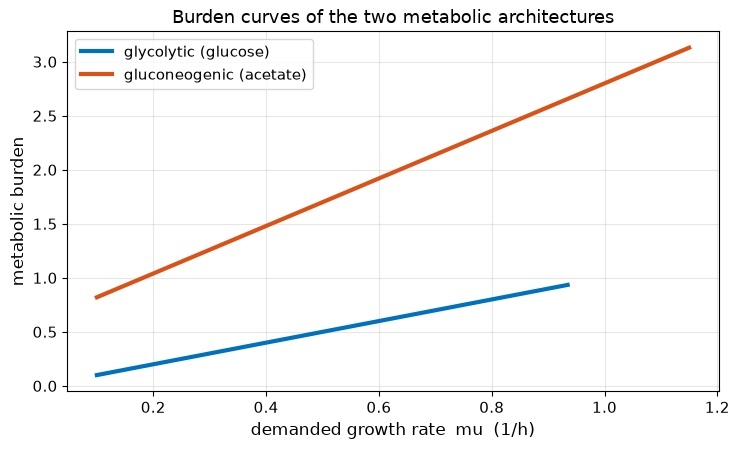

In [3]:
import matplotlib.pyplot as plt

# MATLAB gem colours.
BLUE   = "#0072BD"
ORANGE = "#D95319"

fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(mus, burden_glyc, color=BLUE, lw=3.0, label="glycolytic (glucose)")
ax.plot(mus, burden_gluco, color=ORANGE, lw=3.0, label="gluconeogenic (acetate)")
ax.set_xlabel("demanded growth rate  mu  (1/h)", fontsize=12)
ax.set_ylabel("metabolic burden", fontsize=12)
ax.set_title("Burden curves of the two metabolic architectures", fontsize=13)
ax.legend(fontsize=11, frameon=True, loc="upper left")
ax.grid(True, alpha=0.3, linewidth=0.8)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()


The glycolytic curve (blue) is lower and cheaper but stops at its growth ceiling; the gluconeogenic curve (orange) continues to higher growth rates but sits above glycolytic everywhere they overlap, and it is offset upward by the fixed shunt overhead. Where both are feasible, glycolytic is cheaper to run. The scheduling tension is therefore entirely about *switching*: is it worth switching into the cheaper pathway for a short window if that costs two re-acclimations?


## The environment and the schedule

The environment is a sequence of epochs that alternate substrate and demand. Only the architecture matching the available substrate is admissible per epoch, except a deliberately contested `mixed` epoch (both substrates present) that is *flanked by acetate on both sides*. Choosing the locally cheaper glycolytic pathway for that single mixed epoch therefore forces two extra switches (acetate to glucose-type and back), whereas riding it out on the incumbent gluconeogenic pathway costs none.

We solve the schedule twice: once with a low re-acclimation cost, once with a high one.


In [4]:
epochs = ex18.build_environment()
print("Environment:")
for ep in epochs:
    subs = "/".join(sorted({c.tags["substrate"] for c in ep.candidates}))
    print(f"  {ep.name:<10s} mu={ep.functionality['mu']:.2f}  [{subs}]")

sched_lo = solve_schedule(epochs, cost_fn=ex18.burden_cost, switch_cost=0.05)
sched_hi = solve_schedule(epochs, cost_fn=ex18.burden_cost, switch_cost=0.8)

print("\nLow switch cost (0.05):  ", " -> ".join(sched_lo.schedule),
      f"  ({sched_lo.n_switches} switches)")
print("High switch cost (0.8):  ", " -> ".join(sched_hi.schedule),
      f"  ({sched_hi.n_switches} switches)")


Environment:
  glucose_1  mu=0.80  [glucose]
  acetate_1  mu=0.50  [acetate]
  mixed      mu=0.60  [acetate/glucose]
  acetate_2  mu=0.50  [acetate]
  glucose_2  mu=0.80  [glucose]

Low switch cost (0.05):   glycolytic -> gluconeogenic -> glycolytic -> gluconeogenic -> glycolytic   (4 switches)
High switch cost (0.8):   glycolytic -> gluconeogenic -> gluconeogenic -> gluconeogenic -> glycolytic   (2 switches)


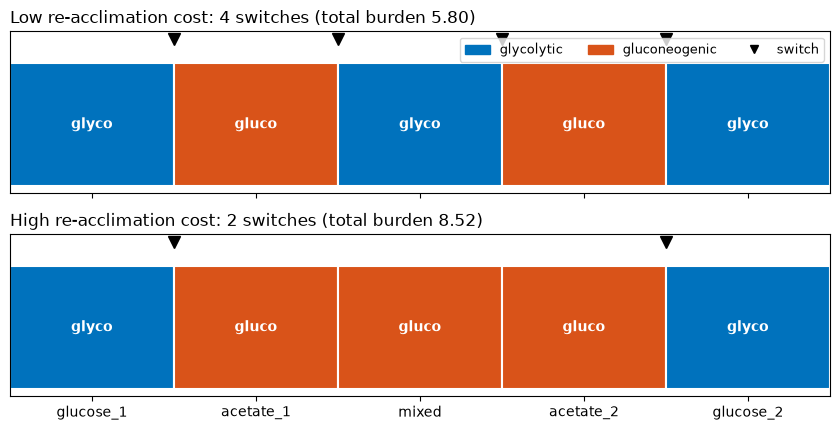

In [5]:
# Visualise the two schedules as coloured tracks across epochs.
fig, axes = plt.subplots(2, 1, figsize=(8.5, 4.4), sharex=True)
names = [ep.name for ep in epochs]
xs = range(len(epochs))

def plot_track(ax, sched, title):
    for i, er in enumerate(sched.epochs):
        c = BLUE if er.architecture == "glycolytic" else ORANGE
        ax.barh(0, 1, left=i, height=0.6, color=c, edgecolor="white", linewidth=1.5)
        ax.text(i + 0.5, 0, er.architecture[:5], ha="center", va="center",
                color="white", fontsize=10, fontweight="bold")
        if er.switch_cost:
            ax.plot(i, 0.42, marker="v", color="black", markersize=9)
    ax.set_yticks([])
    ax.set_xlim(0, len(epochs))
    ax.set_title(title, fontsize=12, loc="left")

plot_track(axes[0], sched_lo,
           f"Low re-acclimation cost: {sched_lo.n_switches} switches "
           f"(total burden {sched_lo.total_cost:.2f})")
plot_track(axes[1], sched_hi,
           f"High re-acclimation cost: {sched_hi.n_switches} switches "
           f"(total burden {sched_hi.total_cost:.2f})")
axes[1].set_xticks([i + 0.5 for i in xs])
axes[1].set_xticklabels(names, fontsize=10)
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color=BLUE, label="glycolytic"),
                        Patch(color=ORANGE, label="gluconeogenic"),
                        plt.Line2D([], [], marker="v", color="black",
                                   linestyle="none", label="switch")],
               loc="upper right", fontsize=9, ncol=3, frameon=True)
fig.tight_layout()
plt.show()


## What the schedule reveals

The `mixed` epoch is the whole story. Under a low re-acclimation cost the organism switches into the cheaper glycolytic pathway for that epoch and pays for two extra switches (the black markers), because the per-epoch burden saving outweighs the switching cost. Under a high re-acclimation cost the same epoch is served by the incumbent gluconeogenic pathway: two switches now cost more than the burden they would save, so the organism rides it out.

This is the diauxic-shift intuition made quantitative. The optimal metabolic schedule is not a property of the environment alone; it depends on the *economics of switching*. The framework surfaces the flip point directly: identical environment, different switching cost, qualitatively different metabolic program. The same `solve_schedule` primitive that handles this organism would handle a vehicle reconfiguring between drivetrain modes or a sensor network swapping topology between survey and tracking phases.
